In [1]:
import torch
import ray_tracing_cuda_float_torch as rt
from algorithms import Algorithms
import matplotlib.pyplot as plt
import time
from skimage.metrics import peak_signal_noise_ratio as psnr


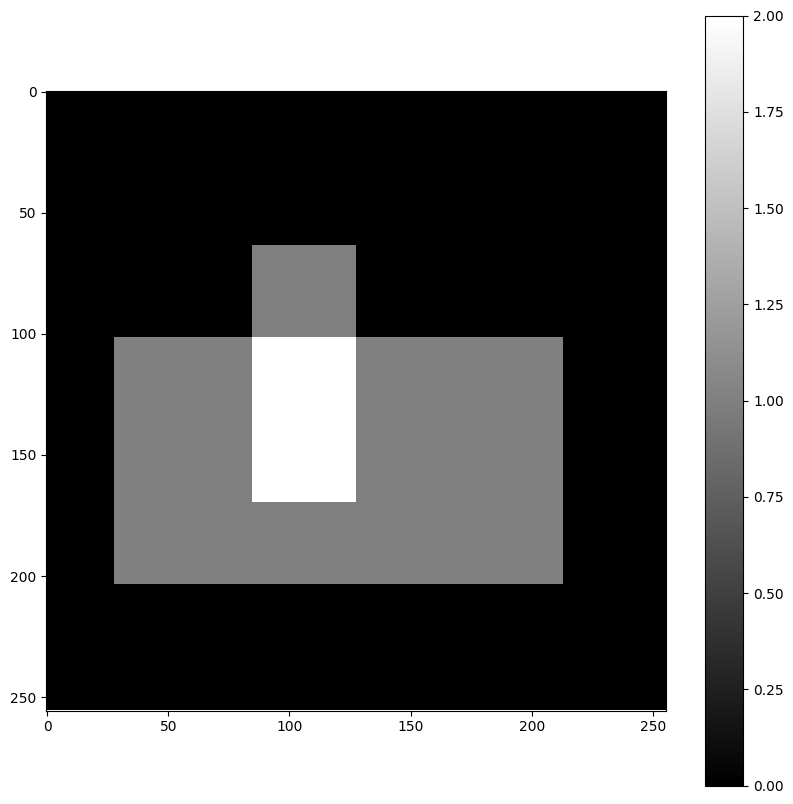

In [2]:
n = 256
img = torch.zeros( ( n, n ), device = 'cuda' )
img[ int( n / 4 ) : int( n / 1.5 ), int( n / 3 ) : int( n / 2 ) ] += 1.0
img[ int( n / 2.5 ) : int( n / 1.25 ), int( n / 9 ) : int( n / 1.2 ) ] += 1.0

plt.figure( figsize = ( 10, 10 ) )
plt.imshow( img.cpu(), cmap = 'gray', interpolation = 'nearest' )
plt.colorbar()
plt.show()

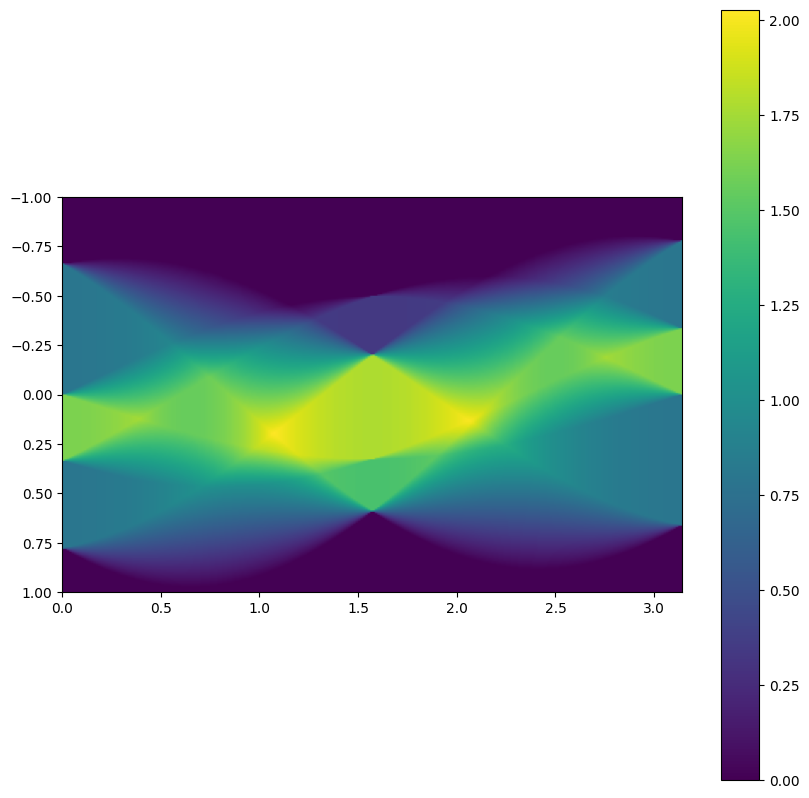

In [3]:
( radon, radon_transpose ) = rt.make_radon_transp(
    ( n, n ),
    sino_top_left = ( 0.0, 1.0 ),
    sino_bottom_right = ( torch.pi, -1.0 ),
    img_shape = ( n, n )    
)

b = radon( img ).clone().detach()
# b = b + 1e-2 * torch.randn_like( b, device = 'cuda' )

plt.figure( figsize = ( 10, 10 ) )
plt.imshow( b.cpu(), extent = ( 0.0, torch.pi, 1.0, -1.0 ) )
plt.colorbar()
plt.show()

In [4]:
#são adjuntas??

x = torch.randn( *img.shape, device = img.device )
y = torch.randn( *img.shape, device = img.device )

print( ( y * radon( x ) ).sum() )
print( ( x * radon_transpose( y ) ).sum() )

#okay

tensor(1.5453, device='cuda:0')
tensor(1.5453, device='cuda:0')


In [5]:
def Q( x ):
    return radon_transpose( radon( x ) )

def f( x ):
    return 1/2 * ( ( radon( x ) - b ) ** 2 ).sum()

def grad_f( x ):
    return radon_transpose( radon( x ) - b )

In [6]:
def spectral_norm( Q, shape, device = 'cuda', n_iter = 50, tol = 1e-6 ):#método das potências
    v = torch.randn( shape, device = device )
    v = v / torch.norm( v )
    
    lambda_old = 0.0
    
    for i in range( n_iter ):
        # 2. Aplica o operador Q(x) = A'A x
        w = Q( v )
        
        lambda_max = torch.sum( v * w ).item()
        
        v = w / torch.norm(w)
        
        if abs( lambda_max - lambda_old ) < tol:
            break
        lambda_old = lambda_max
            
    return lambda_max

L = spectral_norm( Q, ( n, n ) )
print( f"Norma Espectral (L): {L}" )
print( f"Passo máximo (1/L): {1/L}" )

Norma Espectral (L): 3.813915967941284
Passo máximo (1/L): 0.26219770136671117


In [7]:
#vamos fazer um teste rápido do algoritmo aqui
x0 = torch.zeros( n, n, device = 'cuda' )
iters = Algorithms.conjugate( radon, radon_transpose, b, x0 = x0, f = f, tol = 0.0001, max_iter = 1000 )

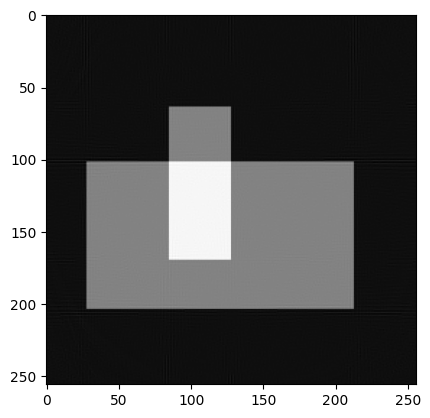

In [8]:
plt.imshow( iters[ -1 ].cpu(), cmap = 'gray' )

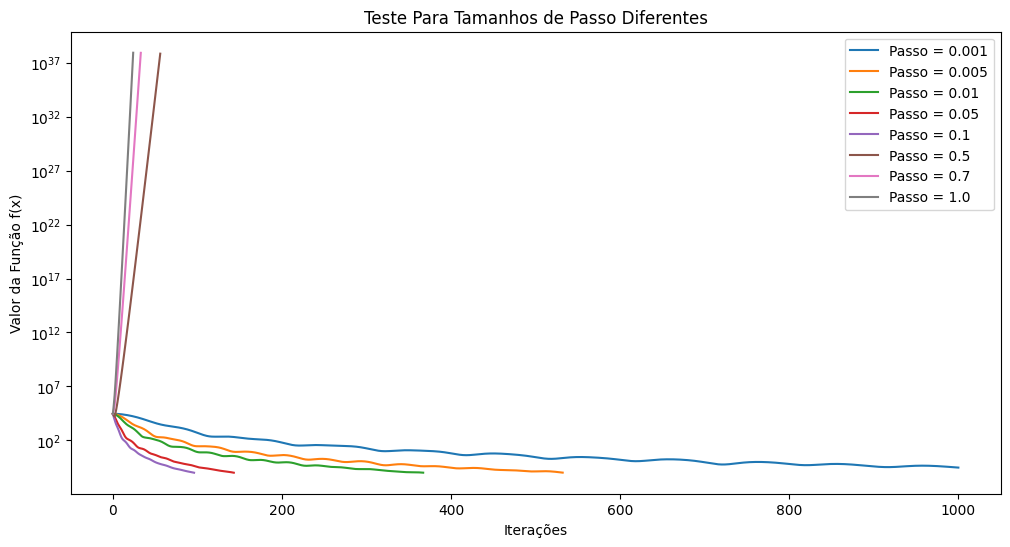

In [9]:
steps = [ 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 0.7, 1.0 ]
x = torch.zeros_like( img, device = 'cuda' )

lista = []
for step in steps:
    iters_nesterov_fixo = Algorithms.nesterov_fixo( f, grad_f, x = x, step = step, tol = 1.0e-1 )
    lista.append( iters_nesterov_fixo )

plt.figure( figsize = ( 12, 6 ) )
for i, step in zip( lista, steps ):
    f_vals_nesterov_fixo = [ f( x ).item() for x in i ]
    plt.semilogy( f_vals_nesterov_fixo, label = f'Passo = {step}' )
plt.title( 'Teste Para Tamanhos de Passo Diferentes' )
plt.xlabel( 'Iterações' )
plt.ylabel( 'Valor da Função f(x)' )
plt.legend()
plt.show()


In [10]:
# def compare_methods( methods, f, grad_f, x0, tol = 1e-4, max_iter = 10000 ):
#     results = {}
#     for name, method in methods.items():
#         print( f"Executando método: {name}" )
#         start_time = time.perf_counter()
#         iters = method( f, grad_f, x0, tol = tol, max_iter = max_iter )
#         end_time = time.perf_counter()

#         exec_time = end_time - start_time
#         values = [ f( x ).item() for x in iters ]

#         results[ name ] = {
#             "iterations": len( iters ),
#             "execution_time": exec_time,
#             "function_values": values,
#             "iters" : iters
#         }
#         print( f"{name}: {len( iters )} iterações, {exec_time:.4f} segundos." )
#     return results

In [11]:
def compare_methods( methods, f, grad_f, x0, tol = 1e-4, max_iter = 10000, runs = 5 ):
    results = {}
    device = x0.device
    is_cuda = device.type == 'cuda'

    for name, method in methods.items():
        print( f"Testando {name} ({runs} execuções)" )
        
        _ = method( f, grad_f, x0, tol = tol, max_iter = max_iter )
        
        times = []
        last_iters = None
        
        for _ in range( runs ):
            if is_cuda:
                torch.cuda.synchronize()
            
            start = time.perf_counter()
            iters = method( f, grad_f, x0, tol = tol, max_iter = max_iter )
            
            if is_cuda:
                torch.cuda.synchronize()
            
            end = time.perf_counter()
            times.append( end - start )
            last_iters = iters

        times_tensor = torch.tensor( times )
        avg_time = torch.mean( times_tensor ).item()
        std_dev = torch.std( times_tensor ).item()
        
        values = [ f( x ).item() for x in last_iters ]
        
        results[ name ] = {
            "iterations": len( last_iters ),
            "avg_time": avg_time,
            "std_dev": std_dev,
            "function_values": values,
            "iters": last_iters
        }
        
        print( f"{name}: {avg_time:.4f}s ± {std_dev:.4f}s ( {len( last_iters )} iterações )" )
    
    return results

# Começando alguns experimentos

In [12]:
x0 = torch.zeros_like( img )
tol = 1e-2
max_iter = 999


In [13]:
methods = {
    "MDBE": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdbe( f, grad_f, A = radon, x0 = x0, tol = tol, max_iter = max_iter ),
    "MDPF": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdpf( f, grad_f, x0 = x0, tol = tol, step = 0.1, max_iter = max_iter ),
    "Nesterov Passo Fixo": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_fixo( f, grad_f, x0, step = 0.1, tol = tol, max_iter = max_iter ),
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( radon, radon_transpose, b, x0, f, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 0.1, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Testando MDBE (5 execuções)
MDBE: 2.9250s ± 0.1851s ( 346 iterações )
Testando MDPF (5 execuções)
MDPF: 6.2332s ± 0.0062s ( 1000 iterações )
Testando Nesterov Passo Fixo (5 execuções)
Nesterov Passo Fixo: 1.1099s ± 0.0008s ( 178 iterações )
Testando Nesterov Busca Exata (5 execuções)
Nesterov Busca Exata: 0.6732s ± 0.0010s ( 85 iterações )
Testando Gradiente Conjugado (5 execuções)
Gradiente Conjugado: 0.1992s ± 0.0009s ( 31 iterações )
Testando Nesterov Backtracking (5 execuções)
Nesterov Backtracking: 1.7367s ± 0.0040s ( 178 iterações )


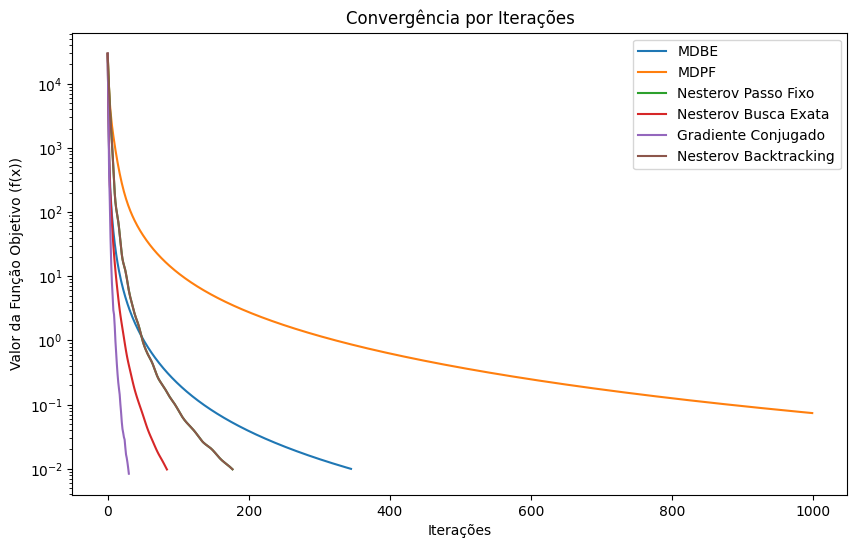

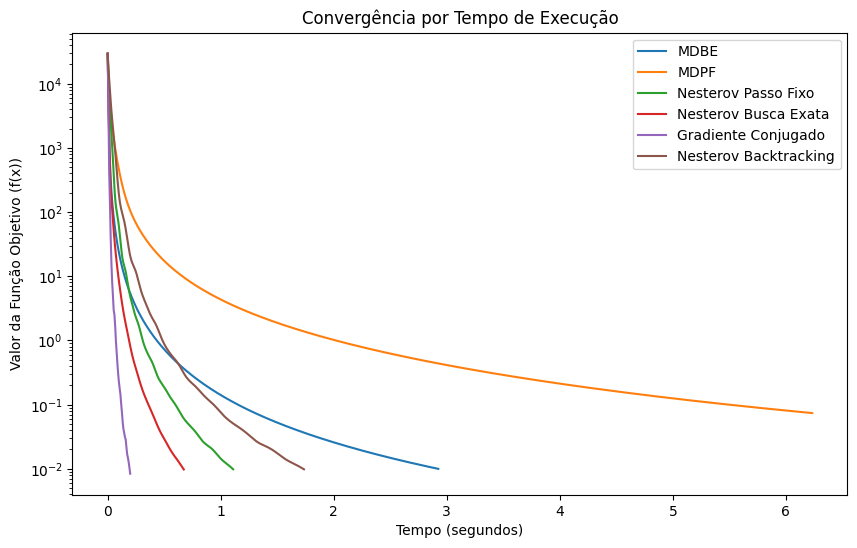

In [14]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "avg_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


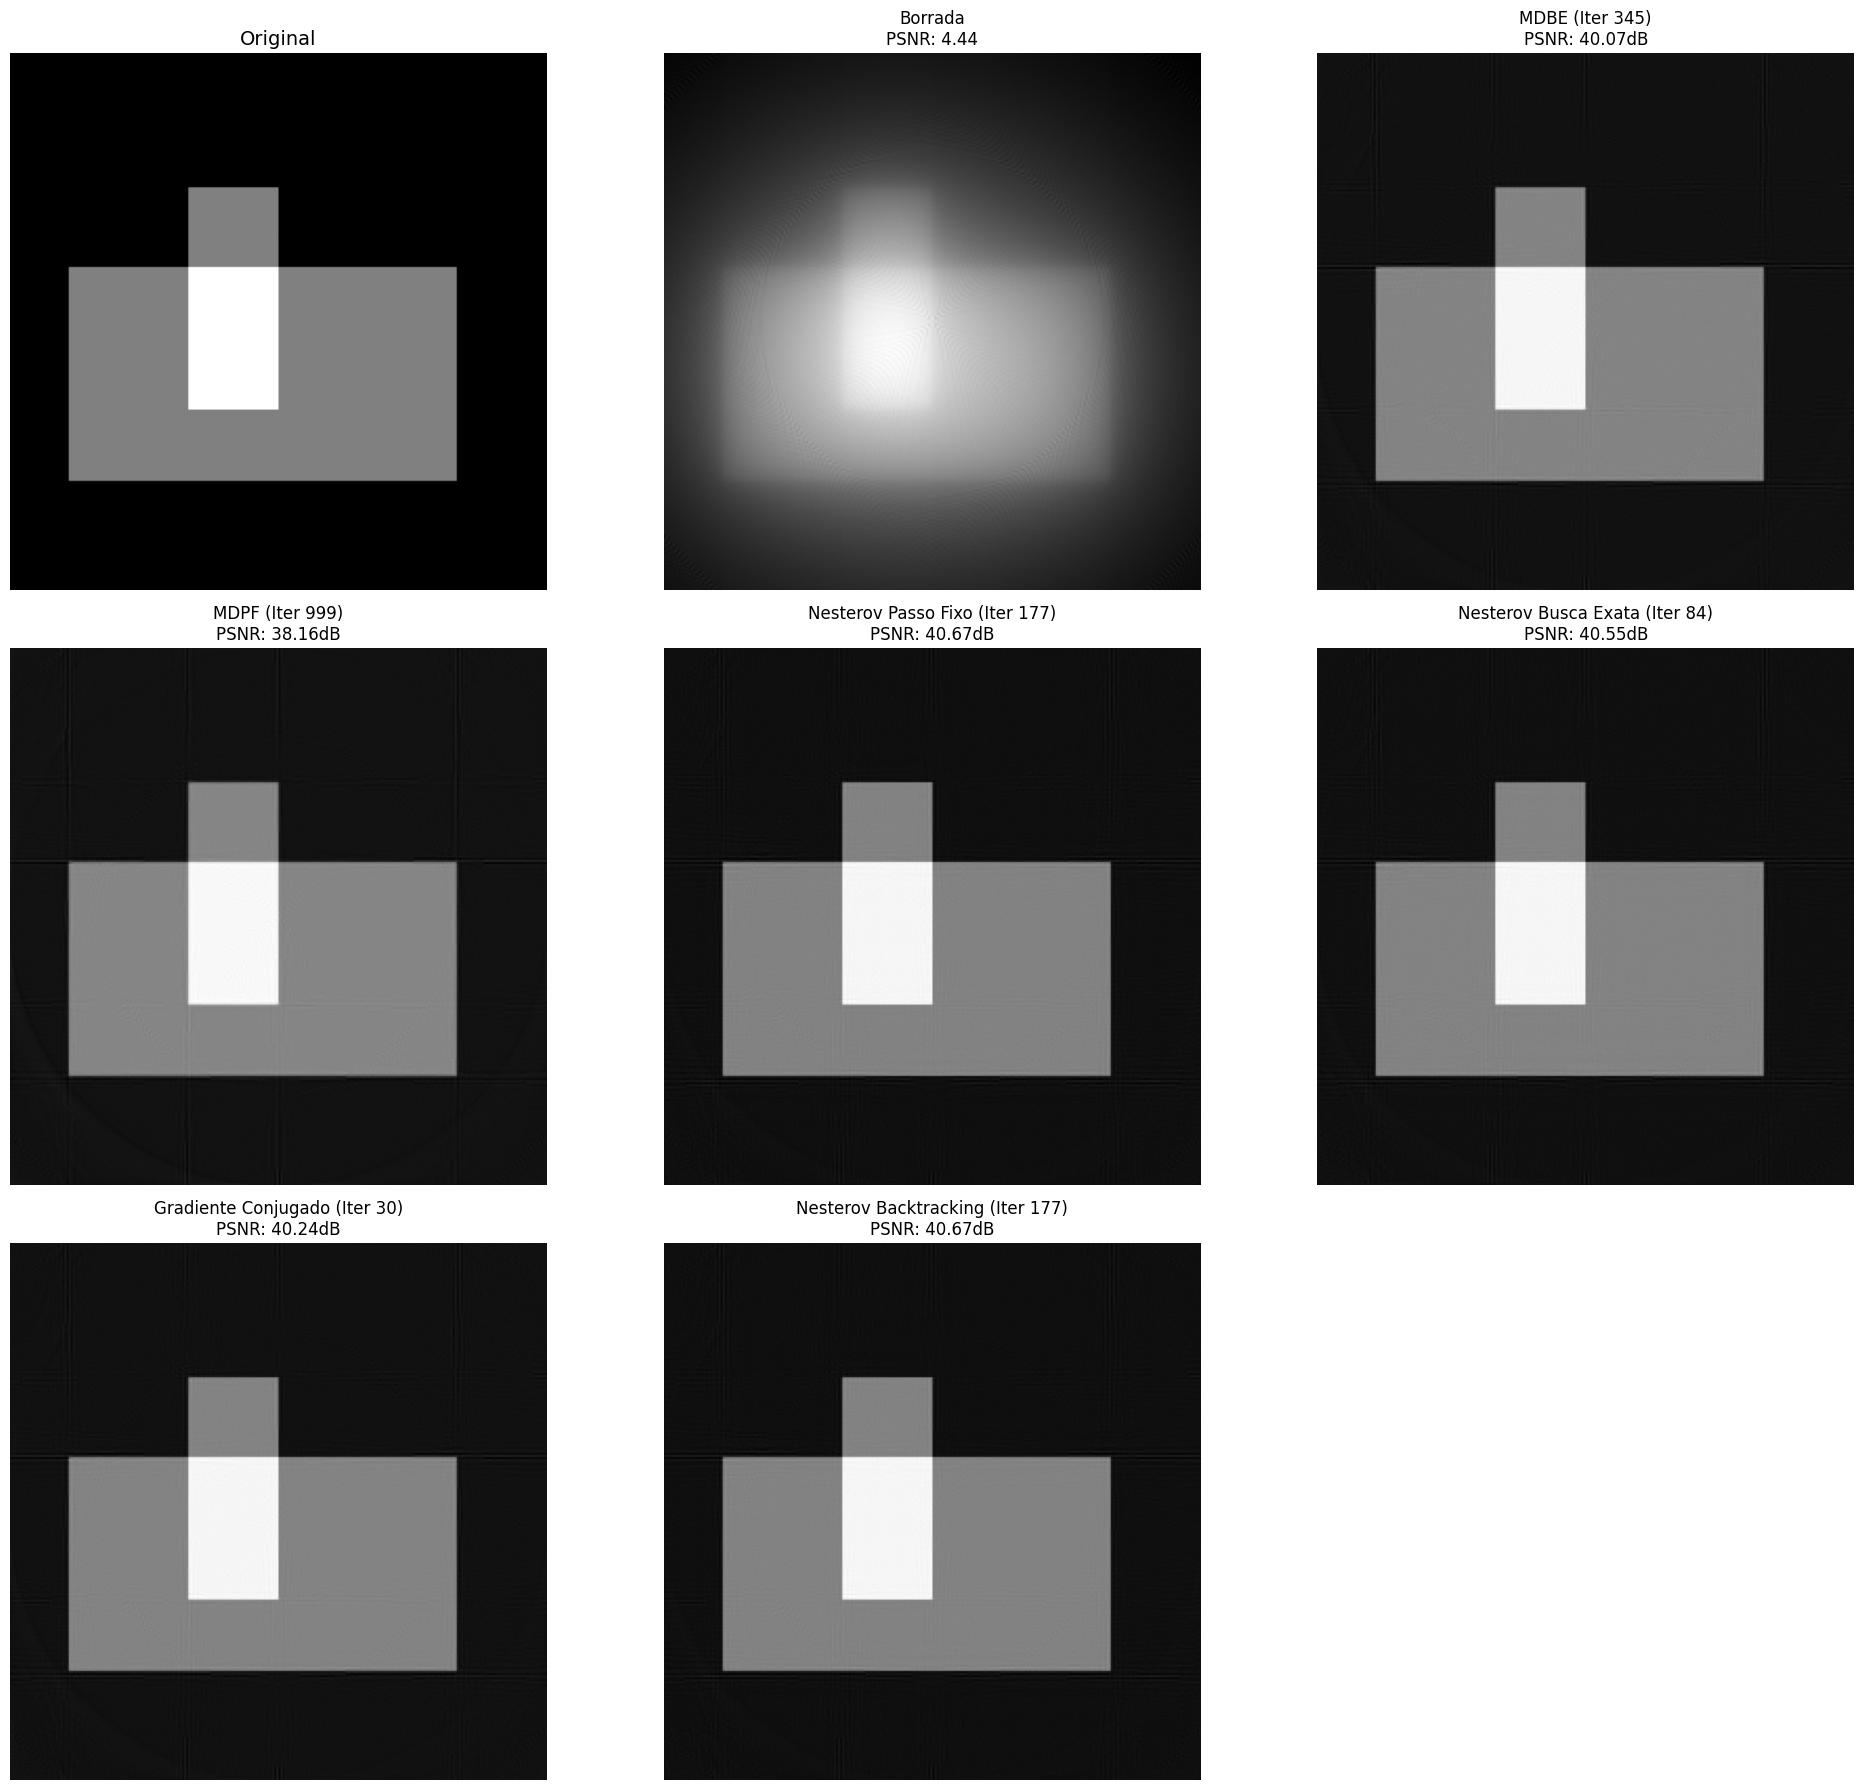

In [15]:
num_basicos = 2
num_algoritmos = len( results )
total_plots = num_basicos + num_algoritmos

cols = 3
rows = ( total_plots + cols - 1 ) // cols

fig, axes = plt.subplots( rows, cols, figsize = ( 20, 6 * rows ) )
axes = axes.flatten()

axes[ 0 ].imshow( img.cpu().numpy(), cmap = plt.cm.gray )
axes[ 0 ].set_title( "Original", fontsize = 14 )

psnr_b = psnr( img.cpu().numpy(), radon_transpose( b ).cpu().numpy(), data_range = img.max() - img.min() )
axes[ 1 ].imshow( radon_transpose( b ).cpu().numpy(), cmap = plt.cm.gray )
axes[ 1 ].set_title( f"Borrada\nPSNR: {psnr_b:.2f}" )

for i, ( name, res ) in enumerate( results.items() ):
    idx_plot = i + num_basicos
    
    melhor_iter = torch.argmin( torch.tensor( res[ "function_values" ] ) )
    recon_best = res[ "iters" ][ melhor_iter ]
    
    img_np = img.cpu().numpy()
    recon_np = recon_best.cpu().numpy()
    d_range = ( img.max() - img.min() ).item()
    
    p_val = psnr( img_np, recon_np, data_range = d_range )
    
    axes[ idx_plot ].imshow( recon_np, cmap = plt.cm.gray )
    axes[ idx_plot ].set_title( f"{name} (Iter {melhor_iter})\nPSNR: {p_val:.2f}dB" )
for j in range( total_plots, len( axes ) ):
    fig.delaxes( axes[ j ] )

for ax in axes:
    ax.axis( "off" )

plt.tight_layout()
plt.show()

# Agora por iterações


In [16]:
x0 = torch.zeros_like( img )
tol = 1e-5
max_iter = 199


In [17]:
methods = {
    "MDBE": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdbe( f, grad_f, A = radon, x0 = x0, tol = tol, max_iter = max_iter ),
    "MDPF": lambda f, grad_f, x0, tol, max_iter: Algorithms.mdpf( f, grad_f, x0 = x0, tol = tol, step = 0.1, max_iter = max_iter ),
    "Nesterov Passo Fixo": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_fixo( f, grad_f, x0, step = 0.1, tol = tol, max_iter = max_iter ),
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( radon, radon_transpose, b, x0, f, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 0.1, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Testando MDBE (5 execuções)
MDBE: 1.8006s ± 0.0368s ( 200 iterações )
Testando MDPF (5 execuções)
MDPF: 1.2516s ± 0.0017s ( 200 iterações )
Testando Nesterov Passo Fixo (5 execuções)
Nesterov Passo Fixo: 1.2568s ± 0.0043s ( 200 iterações )
Testando Nesterov Busca Exata (5 execuções)
Nesterov Busca Exata: 1.6037s ± 0.0020s ( 200 iterações )
Testando Gradiente Conjugado (5 execuções)
Gradiente Conjugado: 1.2851s ± 0.0056s ( 200 iterações )
Testando Nesterov Backtracking (5 execuções)
Nesterov Backtracking: 1.9646s ± 0.0064s ( 200 iterações )


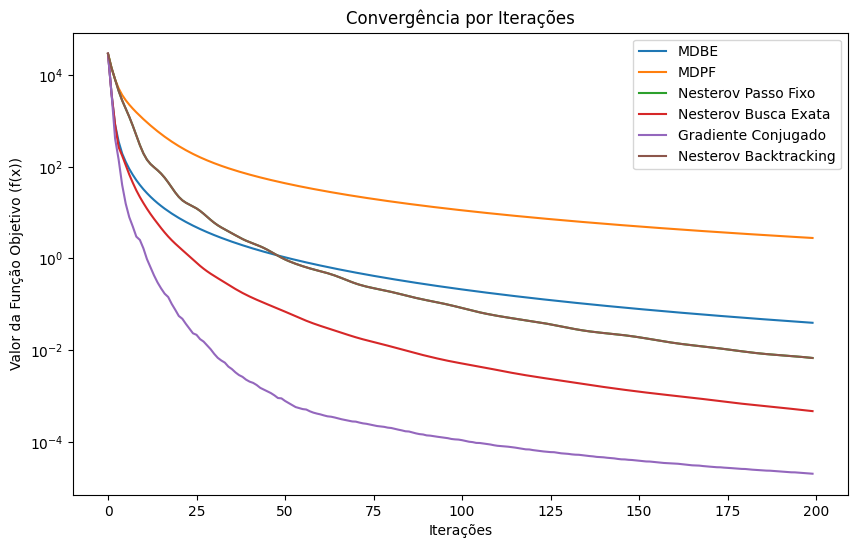

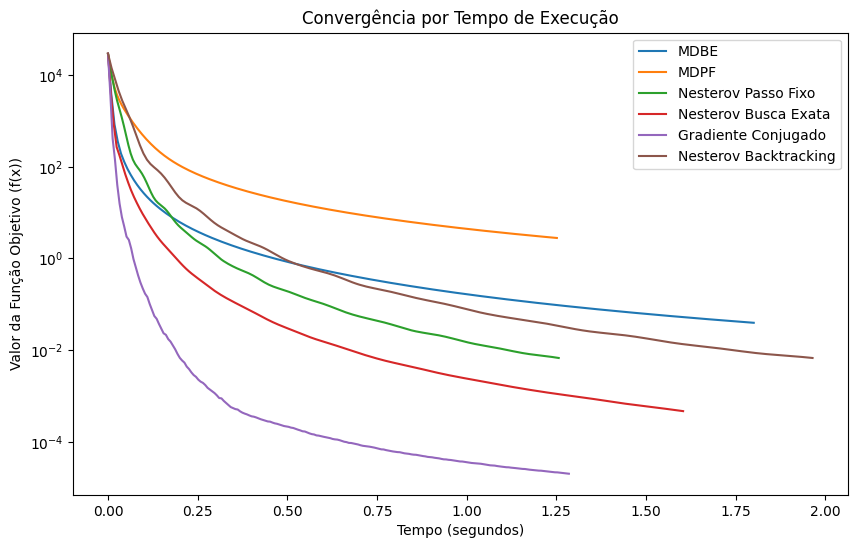

In [18]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "avg_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


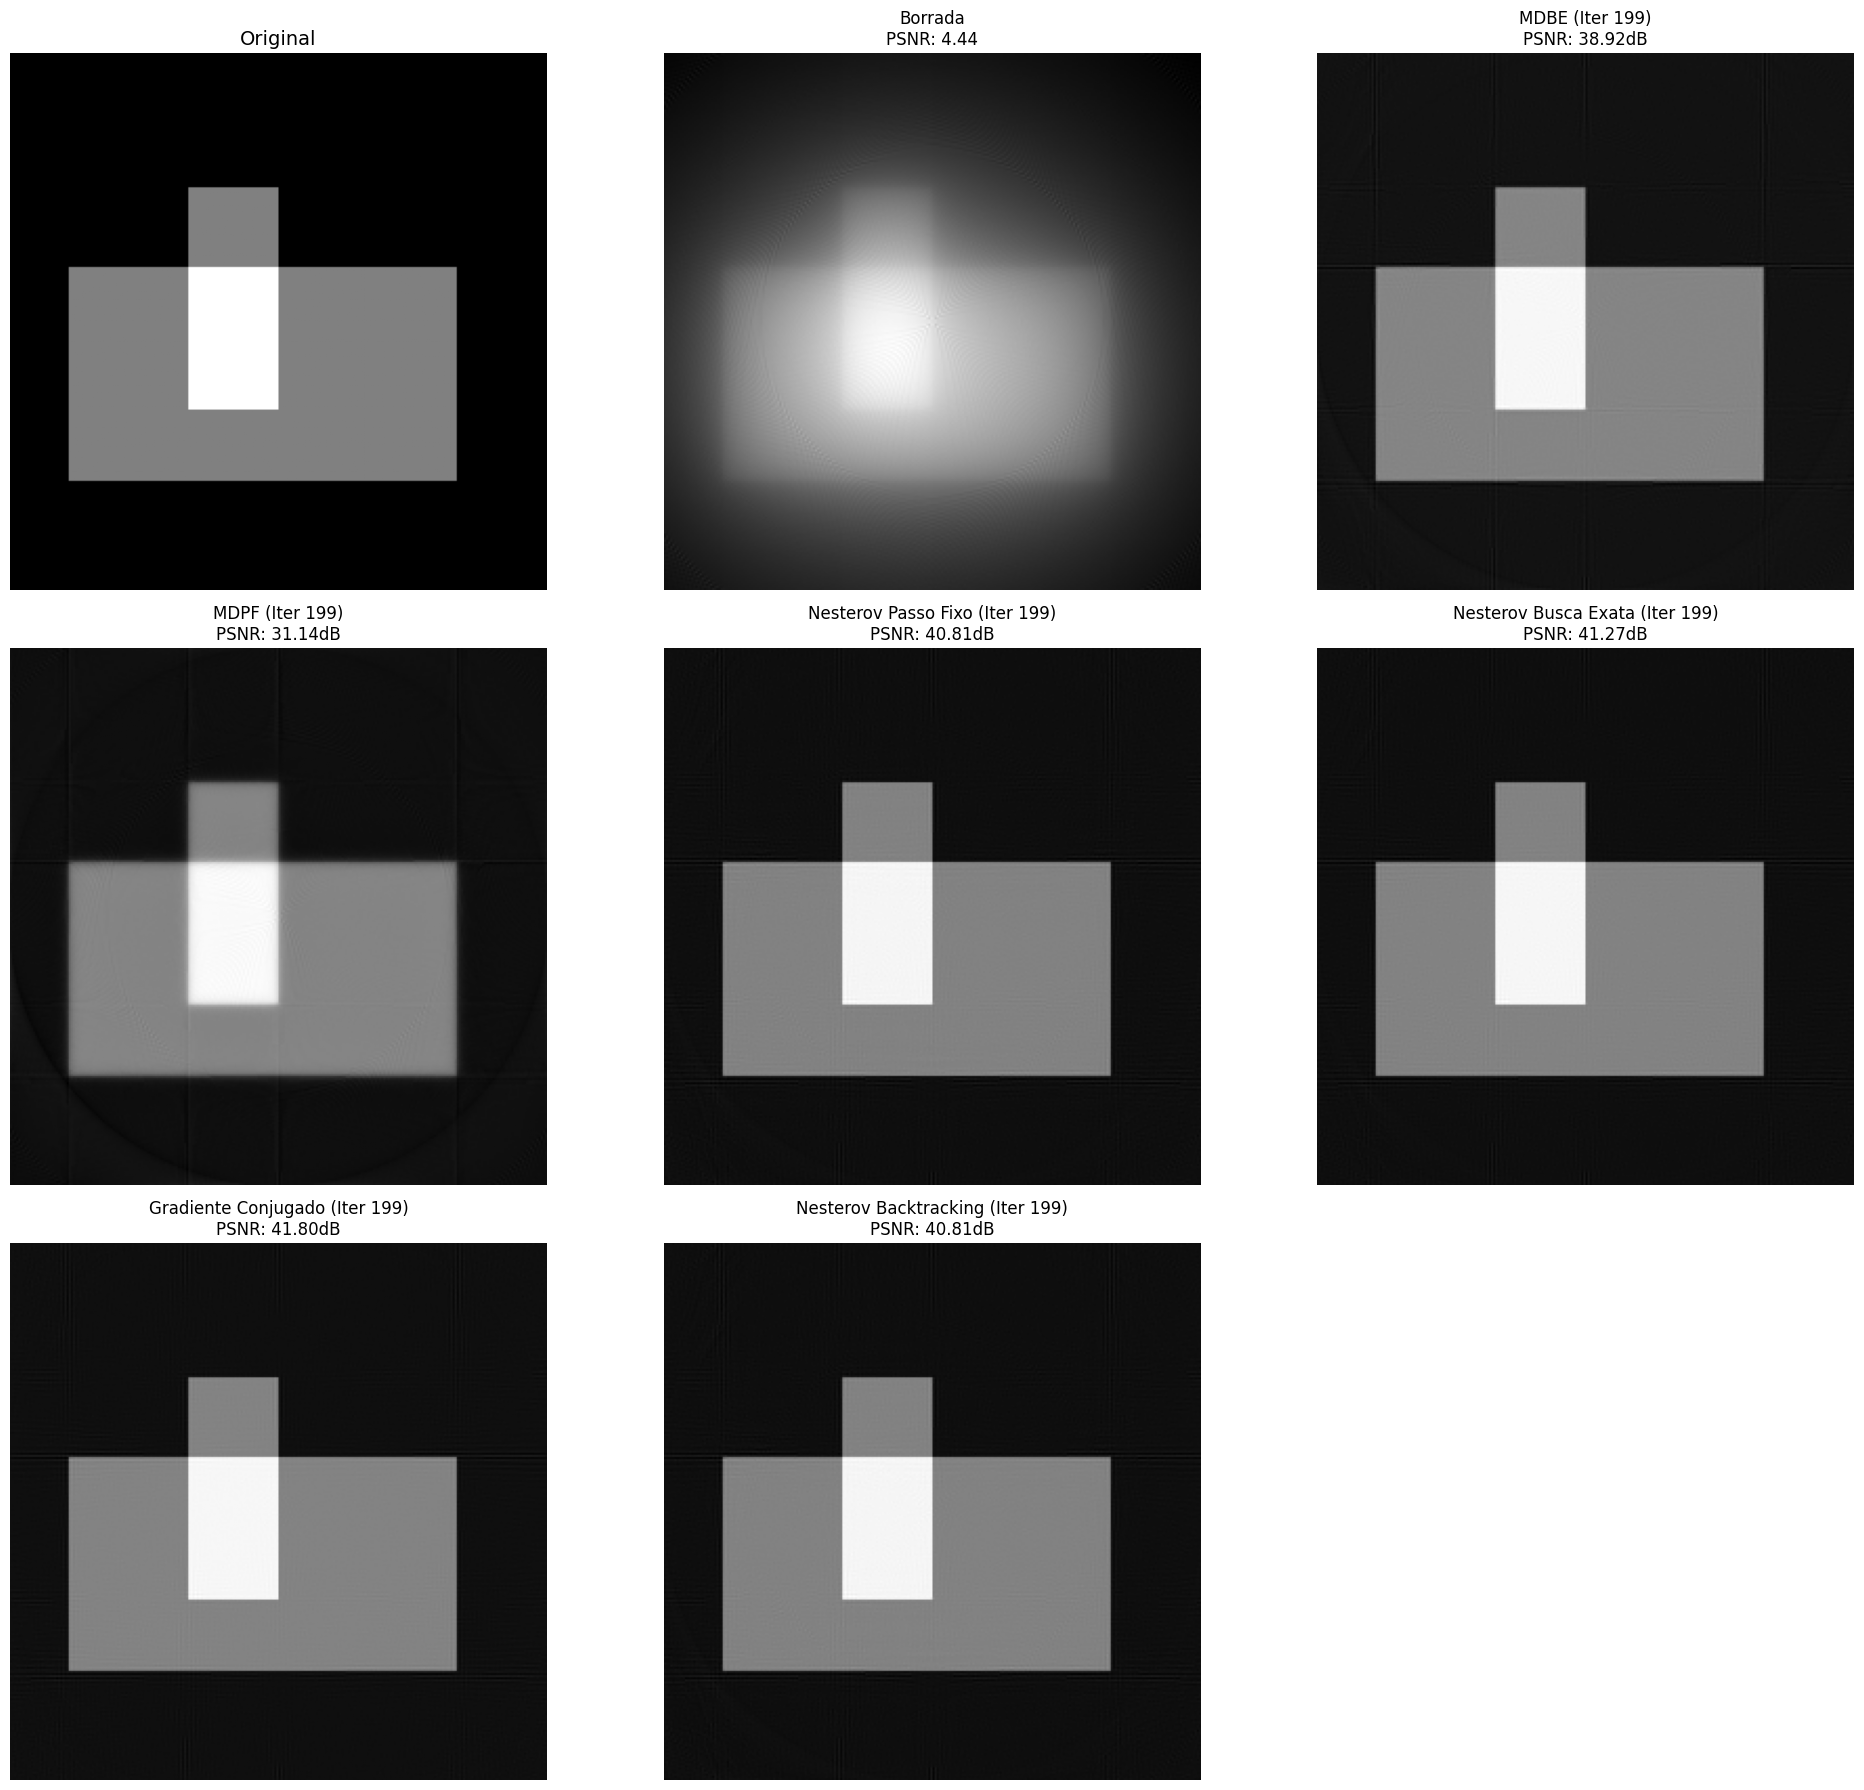

In [19]:
num_basicos = 2
num_algoritmos = len( results )
total_plots = num_basicos + num_algoritmos

cols = 3
rows = ( total_plots + cols - 1 ) // cols

fig, axes = plt.subplots( rows, cols, figsize = ( 20, 6 * rows ) )
axes = axes.flatten()

axes[ 0 ].imshow( img.cpu().numpy(), cmap = plt.cm.gray )
axes[ 0 ].set_title( "Original", fontsize = 14 )

psnr_b = psnr( img.cpu().numpy(), radon_transpose( b ).cpu().numpy(), data_range = img.max() - img.min() )
axes[ 1 ].imshow( radon_transpose( b ).cpu().numpy(), cmap = plt.cm.gray )
axes[ 1 ].set_title( f"Borrada\nPSNR: {psnr_b:.2f}" )

for i, ( name, res ) in enumerate( results.items() ):
    idx_plot = i + num_basicos
    
    melhor_iter = torch.argmin( torch.tensor( res[ "function_values" ] ) )
    recon_best = res[ "iters" ][ melhor_iter ]
    
    img_np = img.cpu().numpy()
    recon_np = recon_best.cpu().numpy()
    d_range = ( img.max() - img.min() ).item()
    
    p_val = psnr( img_np, recon_np, data_range = d_range )
    
    axes[ idx_plot ].imshow( recon_np, cmap = plt.cm.gray )
    axes[ idx_plot ].set_title( f"{name} (Iter {melhor_iter})\nPSNR: {p_val:.2f}dB" )
for j in range( total_plots, len( axes ) ):
    fig.delaxes( axes[ j ] )

for ax in axes:
    ax.axis( "off" )

plt.tight_layout()
plt.show()

# Agora explorando melhor o Nesterov com busca exata e com backtracking

In [20]:
x0 = torch.zeros_like( img )
tol = 1e-5
max_iter = 199

In [21]:
methods = {
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 0.1, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Testando Nesterov Busca Exata (5 execuções)
Nesterov Busca Exata: 1.7802s ± 0.0321s ( 200 iterações )
Testando Nesterov Backtracking (5 execuções)
Nesterov Backtracking: 1.9482s ± 0.0028s ( 200 iterações )


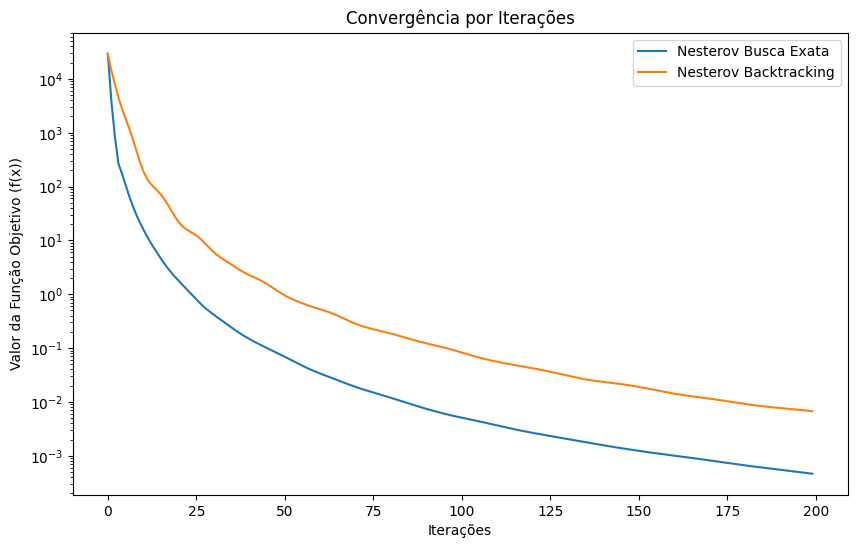

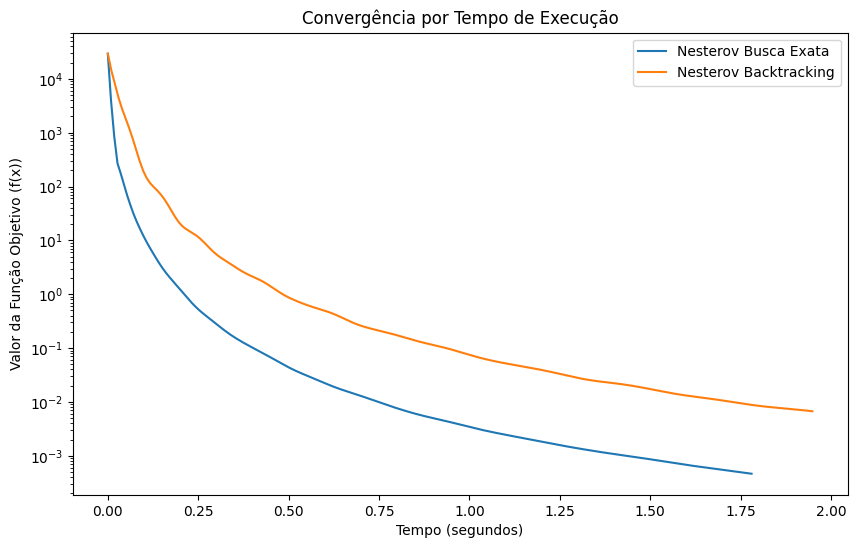

In [22]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "avg_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


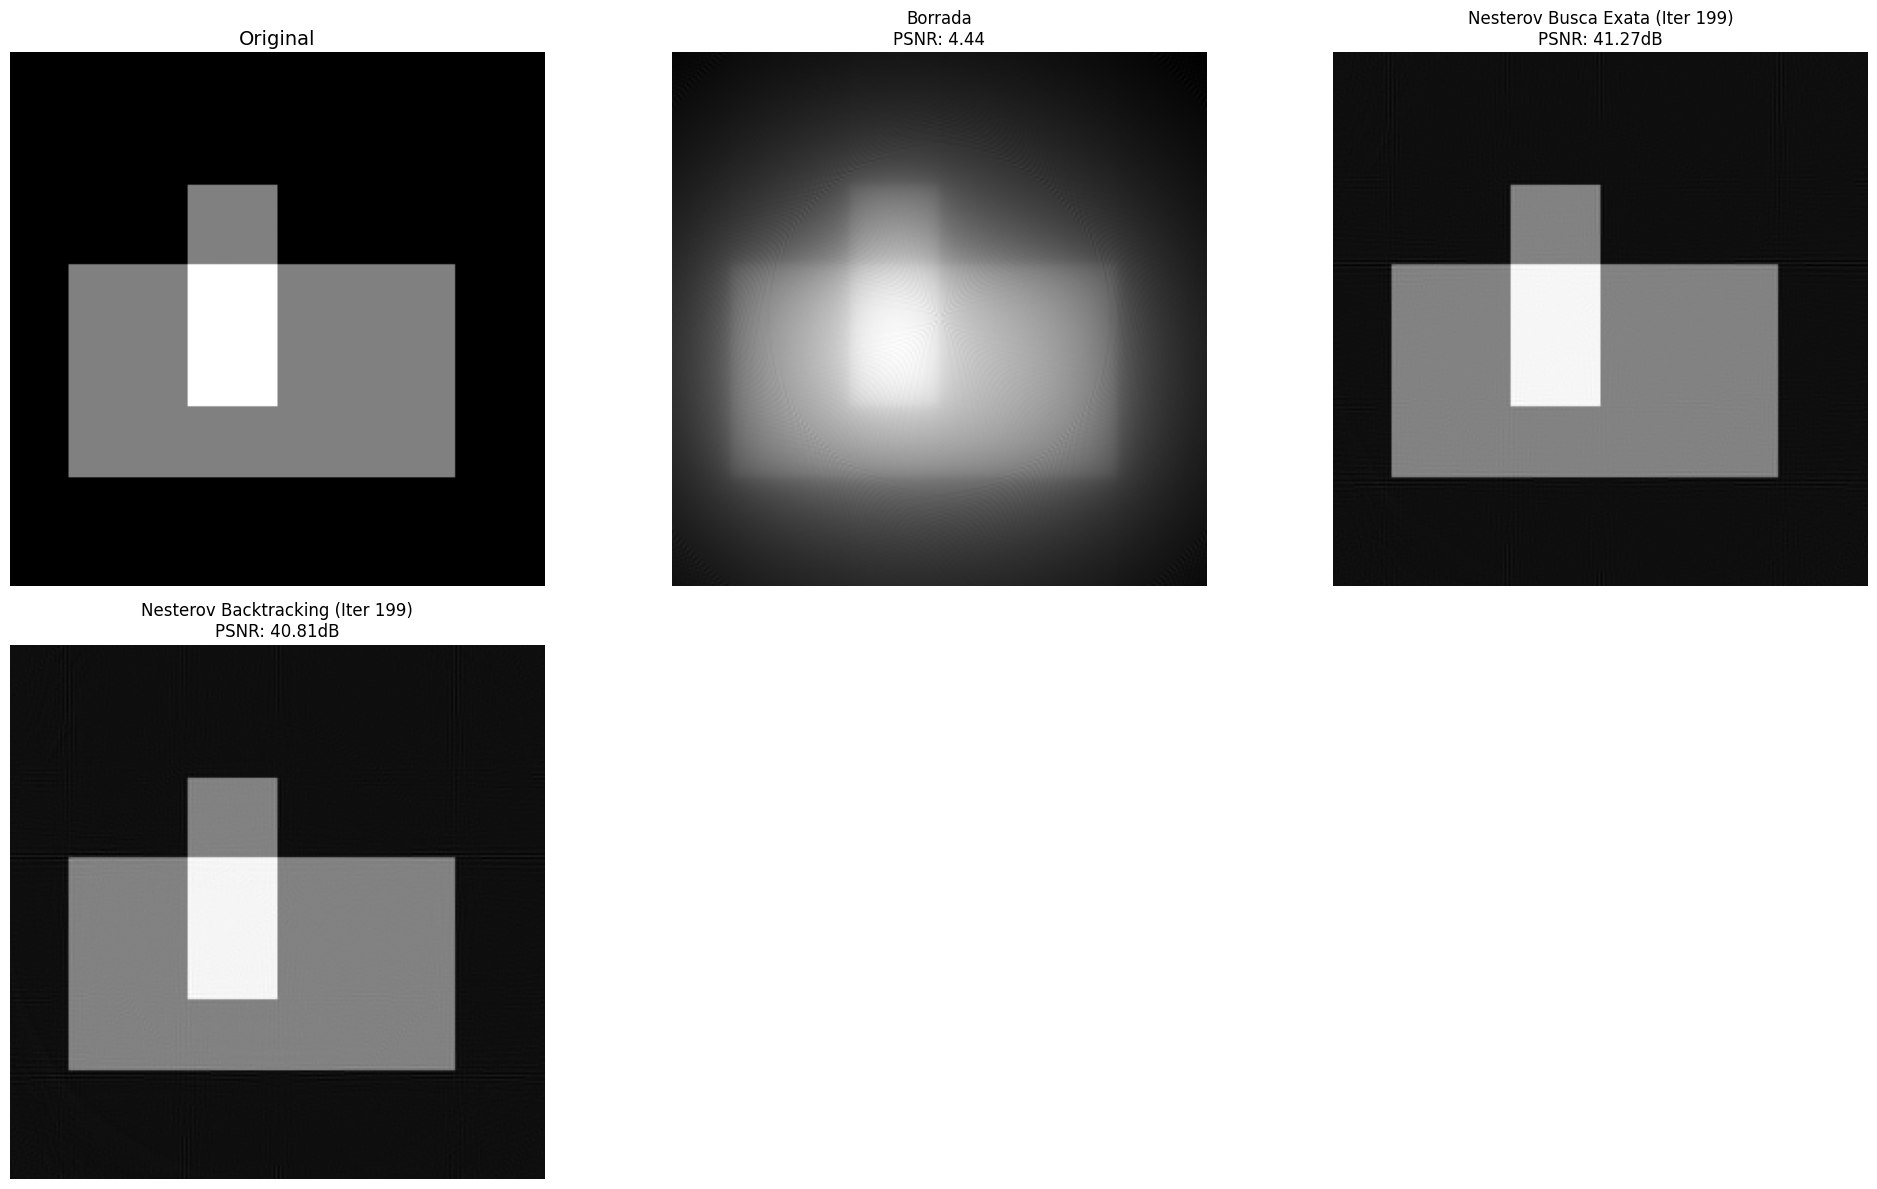

In [23]:
num_basicos = 2
num_algoritmos = len( results )
total_plots = num_basicos + num_algoritmos

cols = 3
rows = ( total_plots + cols - 1 ) // cols

fig, axes = plt.subplots( rows, cols, figsize = ( 20, 6 * rows ) )
axes = axes.flatten()

axes[ 0 ].imshow( img.cpu().numpy(), cmap = plt.cm.gray )
axes[ 0 ].set_title( "Original", fontsize = 14 )

psnr_b = psnr( img.cpu().numpy(), radon_transpose( b ).cpu().numpy(), data_range = img.max() - img.min() )
axes[ 1 ].imshow( radon_transpose( b ).cpu().numpy(), cmap = plt.cm.gray )
axes[ 1 ].set_title( f"Borrada\nPSNR: {psnr_b:.2f}" )

for i, ( name, res ) in enumerate( results.items() ):
    idx_plot = i + num_basicos
    
    melhor_iter = torch.argmin( torch.tensor( res[ "function_values" ] ) )
    recon_best = res[ "iters" ][ melhor_iter ]
    
    img_np = img.cpu().numpy()
    recon_np = recon_best.cpu().numpy()
    d_range = ( img.max() - img.min() ).item()
    
    p_val = psnr( img_np, recon_np, data_range = d_range )
    
    axes[ idx_plot ].imshow( recon_np, cmap = plt.cm.gray )
    axes[ idx_plot ].set_title( f"{name} (Iter {melhor_iter})\nPSNR: {p_val:.2f}dB" )
for j in range( total_plots, len( axes ) ):
    fig.delaxes( axes[ j ] )

for ax in axes:
    ax.axis( "off" )

plt.tight_layout()
plt.show()

In [24]:
x0 = torch.zeros_like( img )
tol = 1e-2
max_iter = 499

In [25]:
methods = {
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter ),
    "Nesterov Backtracking" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_backtracking( f, grad_f, x = x0, step = 0.1, sigma = 1.0e-2, beta = 0.95, tol = tol, max_iter = max_iter)
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Testando Nesterov Busca Exata (5 execuções)
Nesterov Busca Exata: 0.7637s ± 0.0022s ( 85 iterações )
Testando Nesterov Backtracking (5 execuções)
Nesterov Backtracking: 1.8158s ± 0.1140s ( 178 iterações )


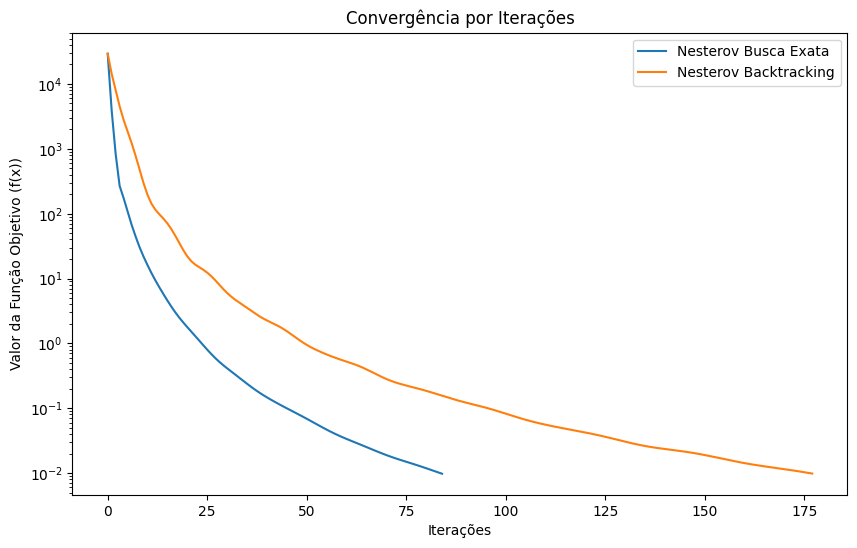

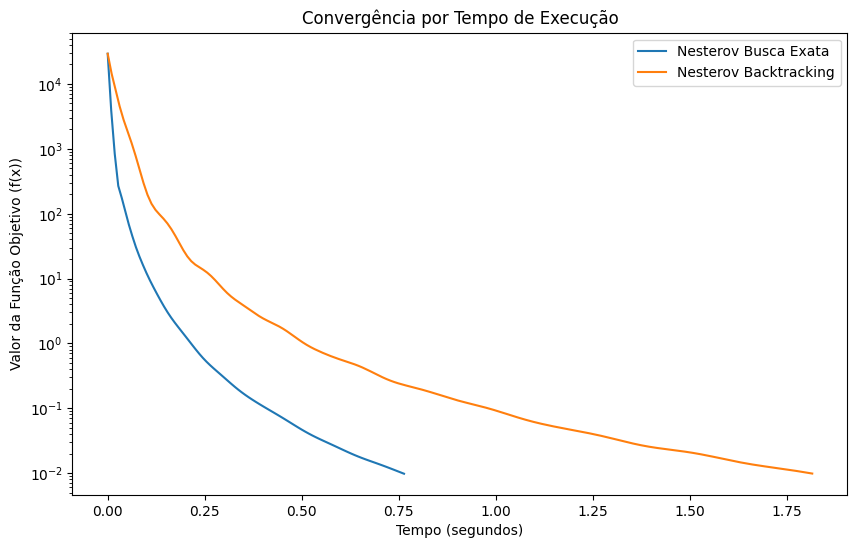

In [26]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "avg_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


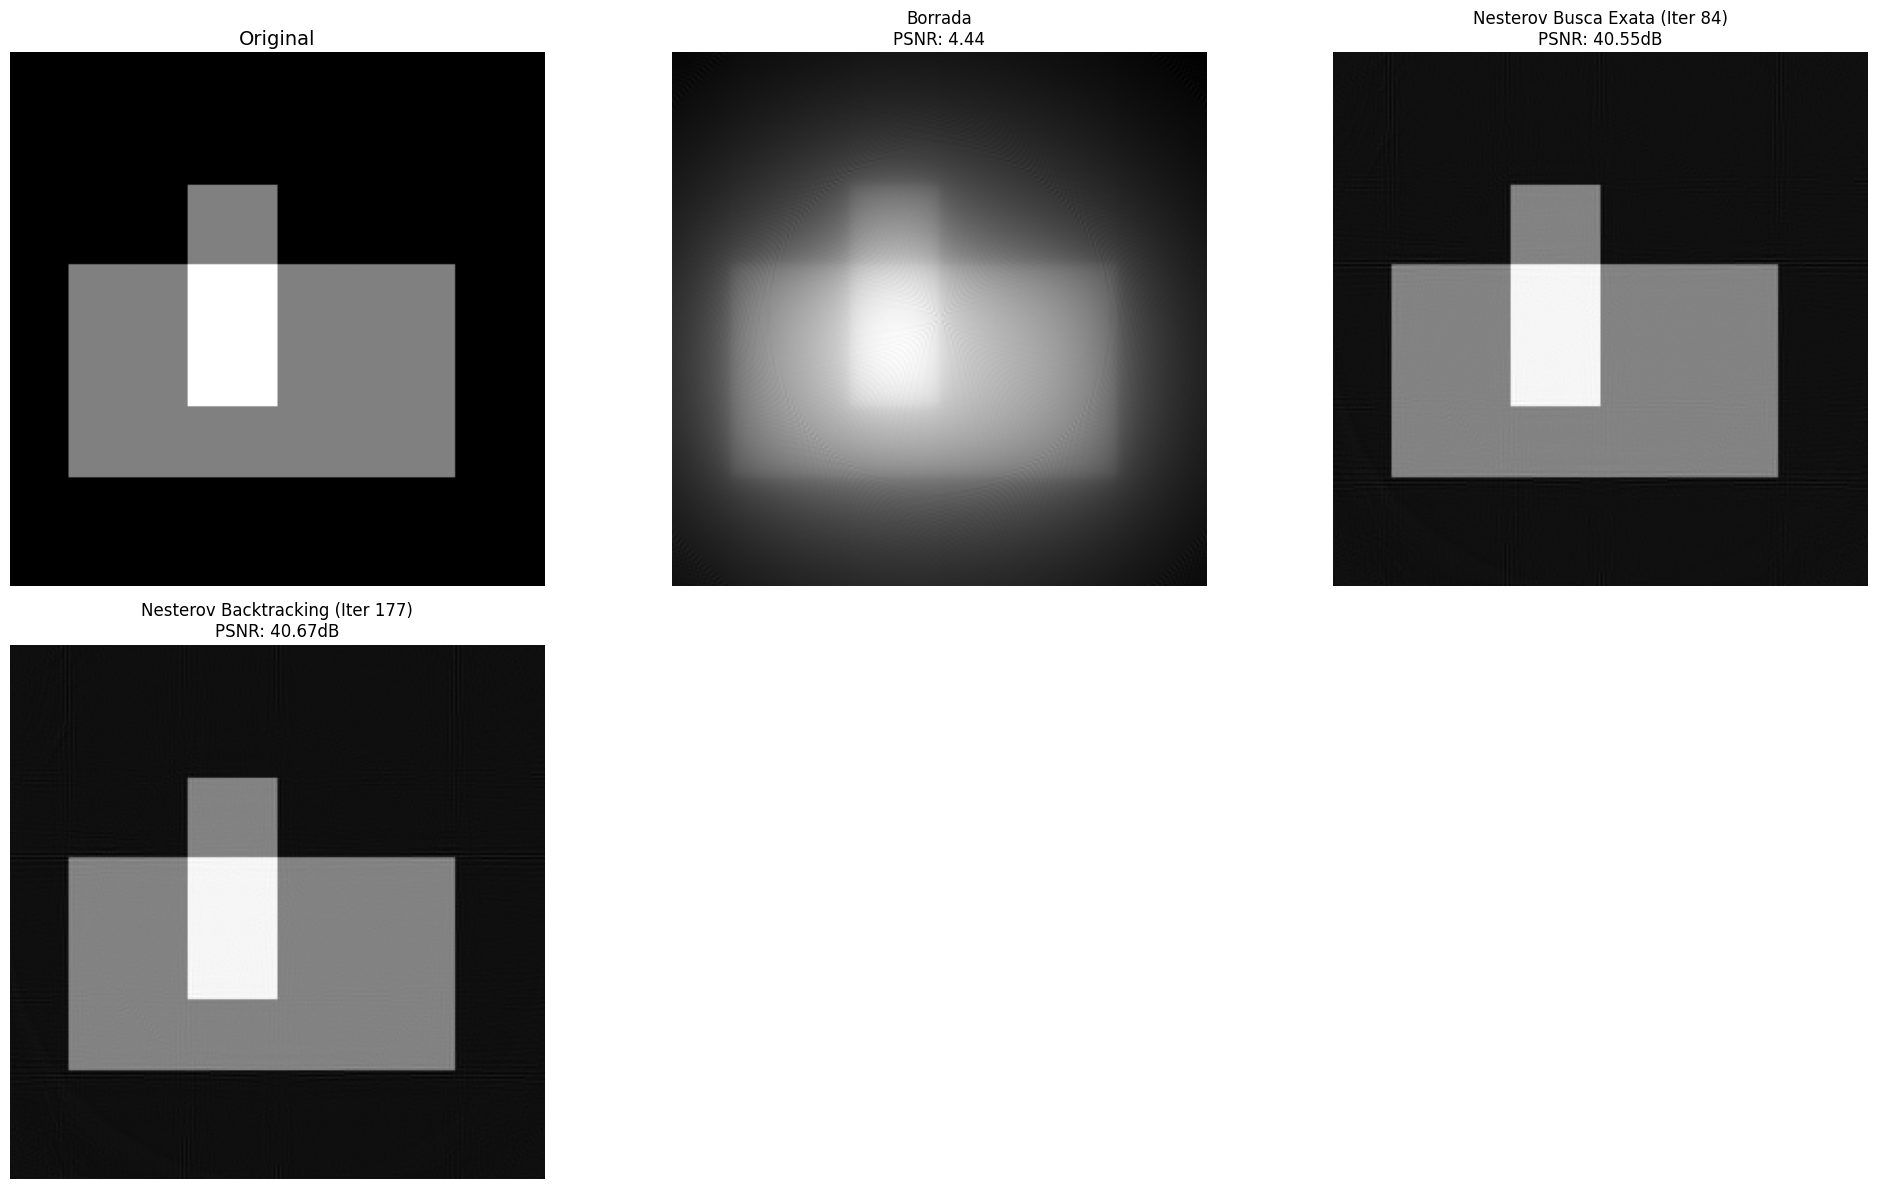

In [27]:
num_basicos = 2
num_algoritmos = len( results )
total_plots = num_basicos + num_algoritmos

cols = 3
rows = ( total_plots + cols - 1 ) // cols

fig, axes = plt.subplots( rows, cols, figsize = ( 20, 6 * rows ) )
axes = axes.flatten()

axes[ 0 ].imshow( img.cpu().numpy(), cmap = plt.cm.gray )
axes[ 0 ].set_title( "Original", fontsize = 14 )

psnr_b = psnr( img.cpu().numpy(), radon_transpose( b ).cpu().numpy(), data_range = img.max() - img.min() )
axes[ 1 ].imshow( radon_transpose( b ).cpu().numpy(), cmap = plt.cm.gray )
axes[ 1 ].set_title( f"Borrada\nPSNR: {psnr_b:.2f}" )

for i, ( name, res ) in enumerate( results.items() ):
    idx_plot = i + num_basicos
    
    melhor_iter = torch.argmin( torch.tensor( res[ "function_values" ] ) )
    recon_best = res[ "iters" ][ melhor_iter ]
    
    img_np = img.cpu().numpy()
    recon_np = recon_best.cpu().numpy()
    d_range = ( img.max() - img.min() ).item()
    
    p_val = psnr( img_np, recon_np, data_range = d_range )
    
    axes[ idx_plot ].imshow( recon_np, cmap = plt.cm.gray )
    axes[ idx_plot ].set_title( f"{name} (Iter {melhor_iter})\nPSNR: {p_val:.2f}dB" )
for j in range( total_plots, len( axes ) ):
    fig.delaxes( axes[ j ] )

for ax in axes:
    ax.axis( "off" )

plt.tight_layout()
plt.show()

# Comparação mais importante, gradientes conjugados com Nesterov busca exata

In [28]:
x0 = torch.zeros_like( img )
tol = 1e-4
max_iter = 999

In [29]:
#Q tem que ser simétrica para o gc funcionar bem, isto é <u, Qv> = <Qu, v> = uTQTv, para todos u e v
u = torch.randn_like( x0 )
v = torch.randn_like( x0 )
Qu = Q( u )
Qv = Q( v )
dot1 = torch.sum( u * Qv )
dot2 = torch.sum( Qu * v )
print( f"Simetria: {dot1 - dot2:.2e}" )
#nao é simétrico entao

Simetria: 2.86e-06


In [30]:
methods = {
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( radon, radon_transpose, b, x0, f, tol = tol, max_iter = max_iter ),
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )

Testando Nesterov Busca Exata (5 execuções)
Nesterov Busca Exata: 2.7571s ± 0.1865s ( 322 iterações )
Testando Gradiente Conjugado (5 execuções)
Gradiente Conjugado: 0.7503s ± 0.0158s ( 102 iterações )


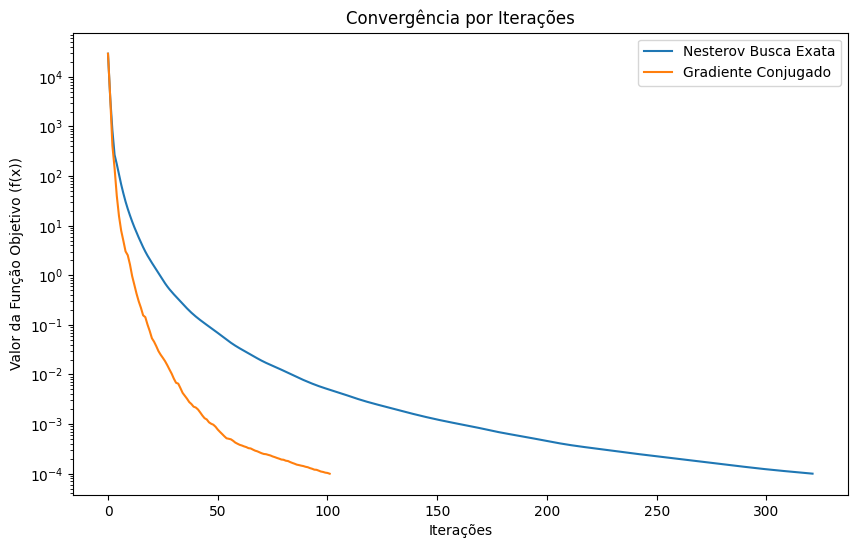

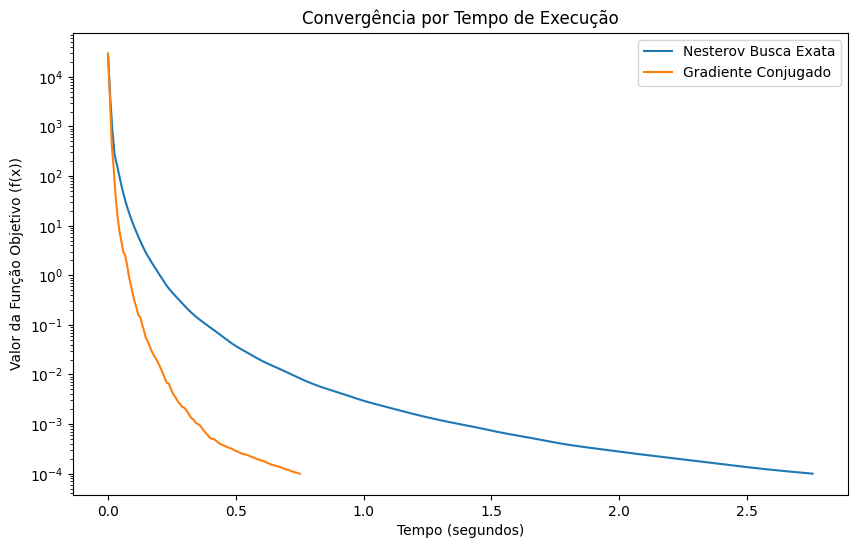

In [31]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "avg_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


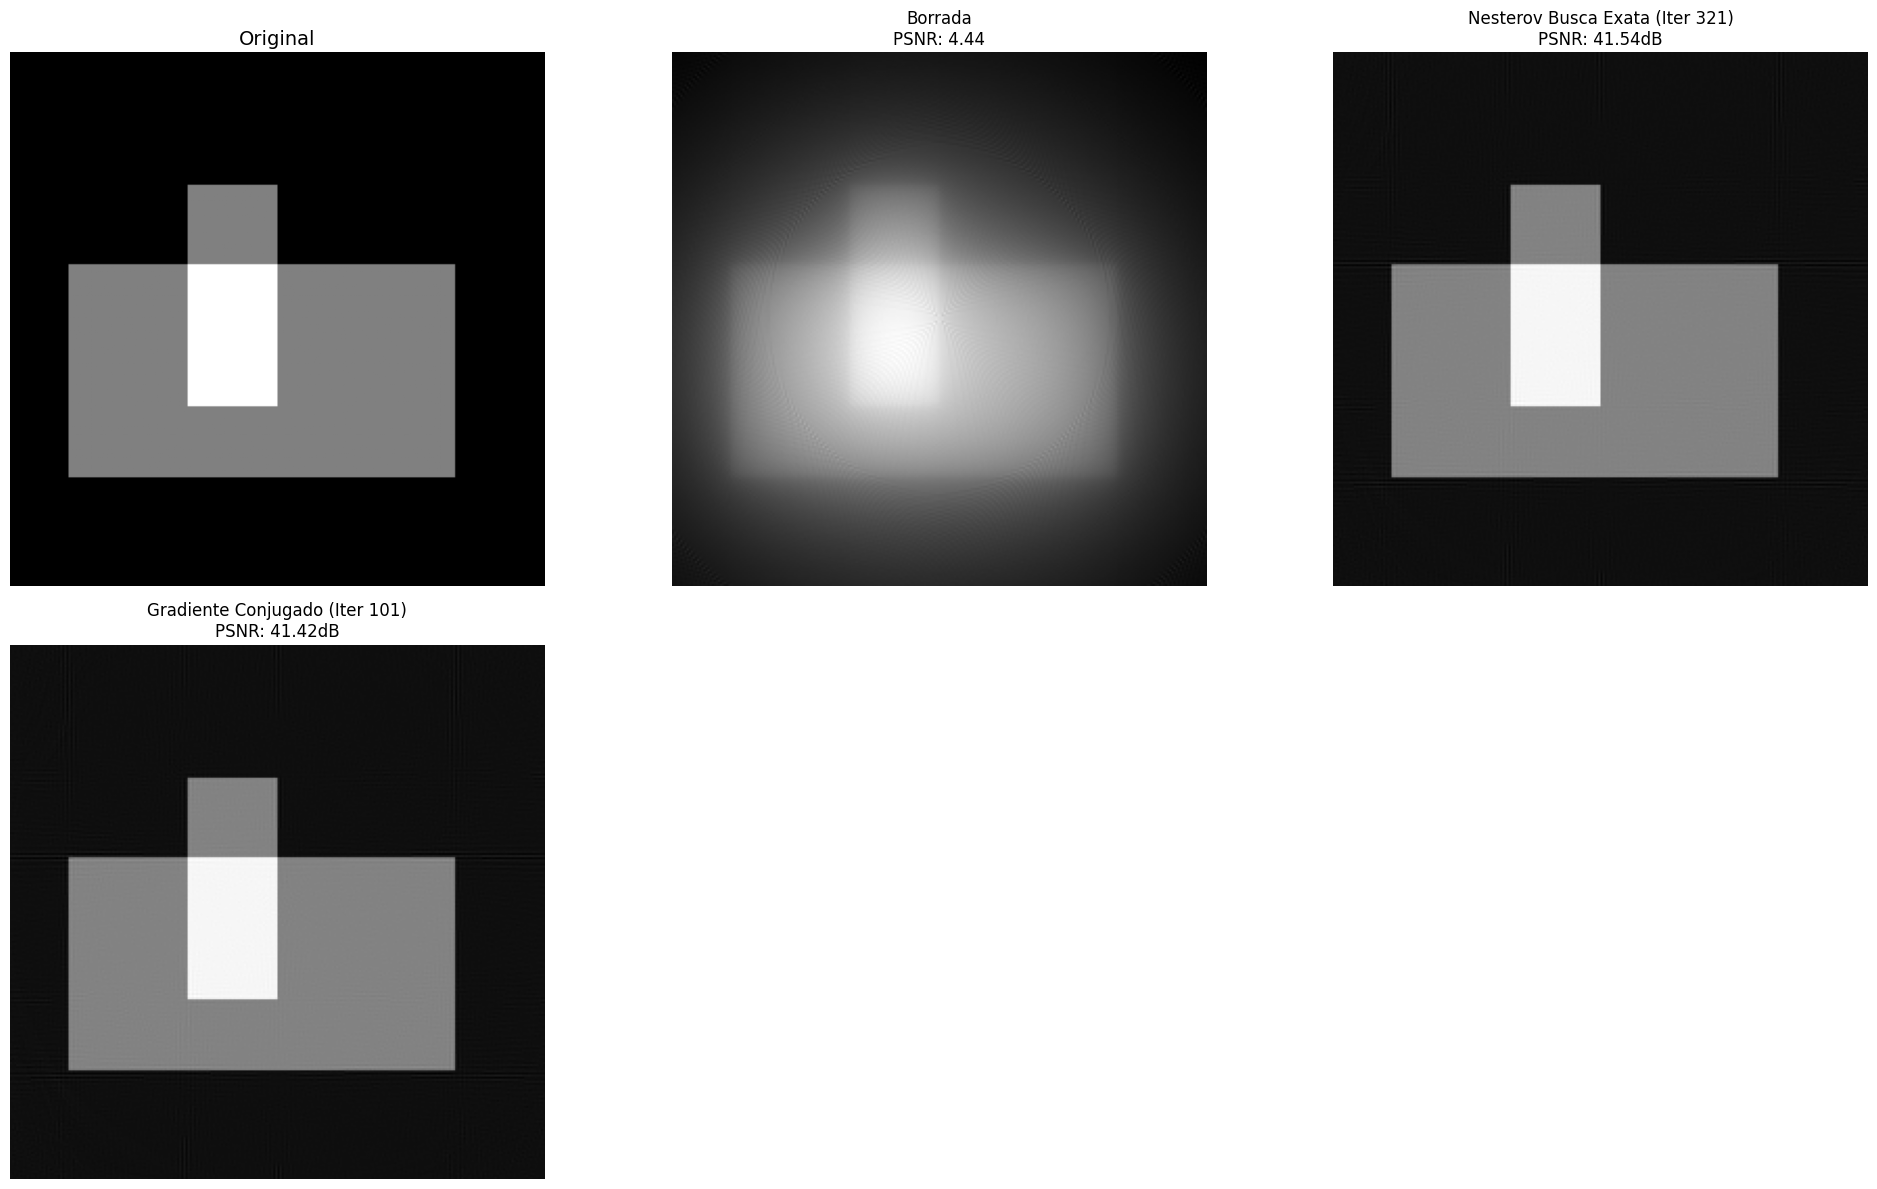

In [32]:
num_basicos = 2
num_algoritmos = len( results )
total_plots = num_basicos + num_algoritmos

cols = 3
rows = ( total_plots + cols - 1 ) // cols

fig, axes = plt.subplots( rows, cols, figsize = ( 20, 6 * rows ) )
axes = axes.flatten()

axes[ 0 ].imshow( img.cpu().numpy(), cmap = plt.cm.gray )
axes[ 0 ].set_title( "Original", fontsize = 14 )

psnr_b = psnr( img.cpu().numpy(), radon_transpose( b ).cpu().numpy(), data_range = img.max() - img.min() )
axes[ 1 ].imshow( radon_transpose( b ).cpu().numpy(), cmap = plt.cm.gray )
axes[ 1 ].set_title( f"Borrada\nPSNR: {psnr_b:.2f}" )

for i, ( name, res ) in enumerate( results.items() ):
    idx_plot = i + num_basicos
    
    melhor_iter = torch.argmin( torch.tensor( res[ "function_values" ] ) )
    recon_best = res[ "iters" ][ melhor_iter ]
    
    img_np = img.cpu().numpy()
    recon_np = recon_best.cpu().numpy()
    d_range = ( img.max() - img.min() ).item()
    
    p_val = psnr( img_np, recon_np, data_range = d_range )
    
    axes[ idx_plot ].imshow( recon_np, cmap = plt.cm.gray )
    axes[ idx_plot ].set_title( f"{name} (Iter {melhor_iter})\nPSNR: {p_val:.2f}dB" )
for j in range( total_plots, len( axes ) ):
    fig.delaxes( axes[ j ] )

for ax in axes:
    ax.axis( "off" )

plt.tight_layout()
plt.show()

In [33]:
x0 = torch.zeros_like( img )
tol = 1e-5
max_iter = 1499

In [34]:
methods = {
    "Nesterov Busca Exata": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter ),
    "Gradiente Conjugado" : lambda f, grad_f, x0, tol, max_iter: Algorithms.conjugate( radon, radon_transpose, b, x0, f, tol = tol, max_iter = max_iter ),
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )

Testando Nesterov Busca Exata (5 execuções)
Nesterov Busca Exata: 7.2849s ± 0.0574s ( 787 iterações )
Testando Gradiente Conjugado (5 execuções)
Gradiente Conjugado: 2.1013s ± 0.1050s ( 290 iterações )


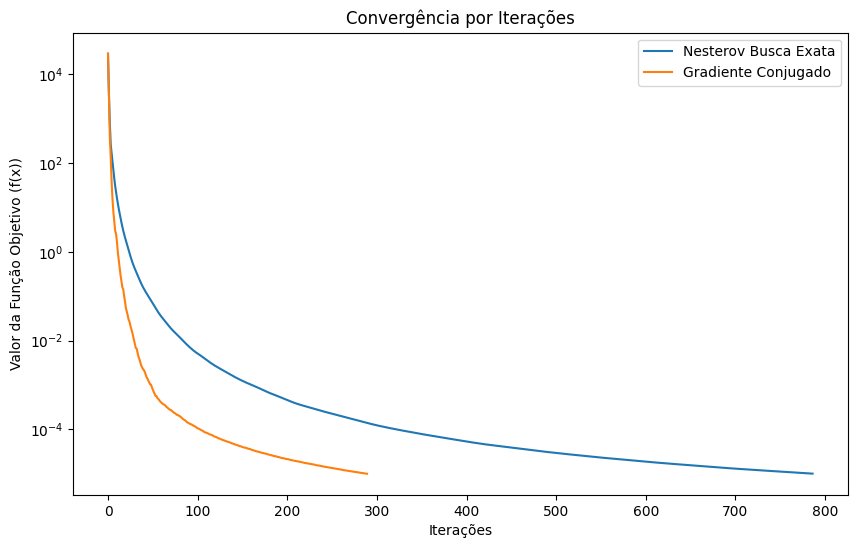

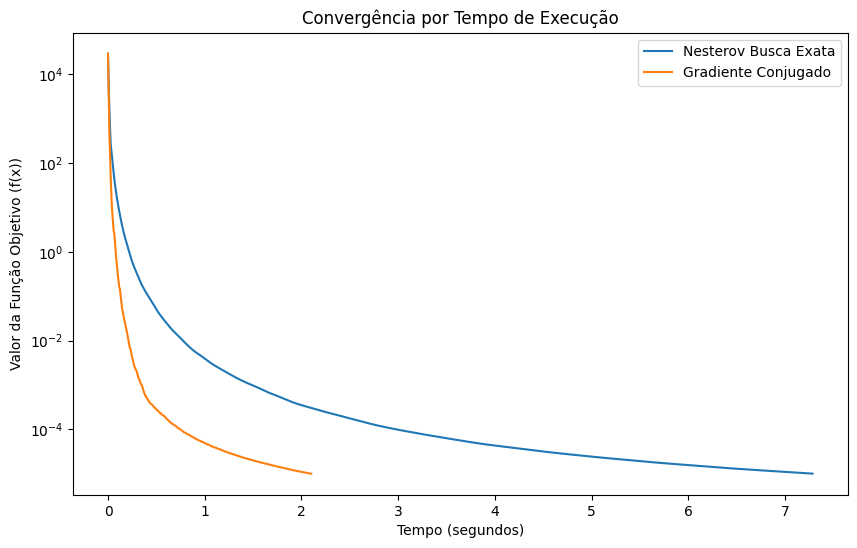

In [35]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "avg_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


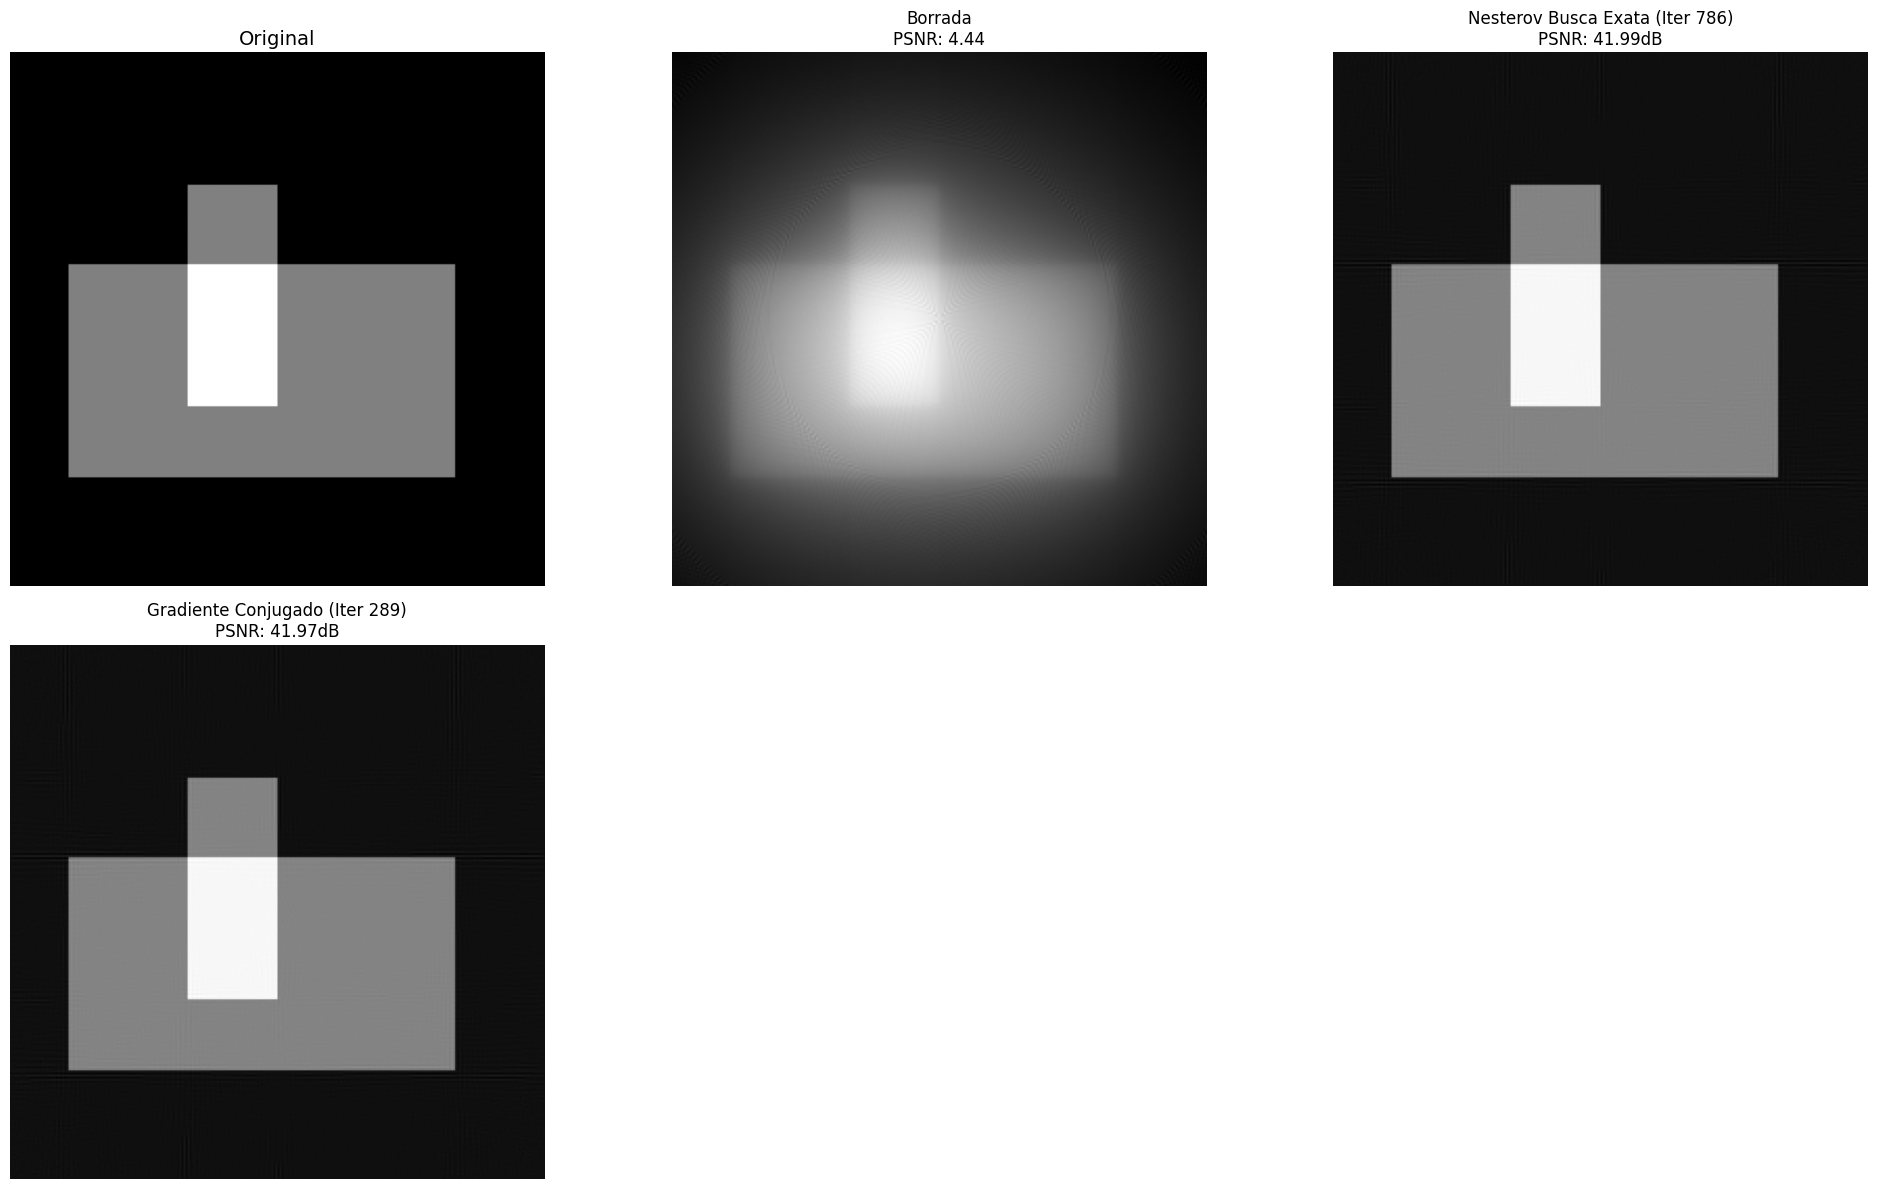

In [36]:
num_basicos = 2
num_algoritmos = len( results )
total_plots = num_basicos + num_algoritmos

cols = 3
rows = ( total_plots + cols - 1 ) // cols

fig, axes = plt.subplots( rows, cols, figsize = ( 20, 6 * rows ) )
axes = axes.flatten()

axes[ 0 ].imshow( img.cpu().numpy(), cmap = plt.cm.gray )
axes[ 0 ].set_title( "Original", fontsize = 14 )

psnr_b = psnr( img.cpu().numpy(), radon_transpose( b ).cpu().numpy(), data_range = img.max() - img.min() )
axes[ 1 ].imshow( radon_transpose( b ).cpu().numpy(), cmap = plt.cm.gray )
axes[ 1 ].set_title( f"Borrada\nPSNR: {psnr_b:.2f}" )

for i, ( name, res ) in enumerate( results.items() ):
    idx_plot = i + num_basicos
    
    melhor_iter = torch.argmin( torch.tensor( res[ "function_values" ] ) )
    recon_best = res[ "iters" ][ melhor_iter ]
    
    img_np = img.cpu().numpy()
    recon_np = recon_best.cpu().numpy()
    d_range = ( img.max() - img.min() ).item()
    
    p_val = psnr( img_np, recon_np, data_range = d_range )
    
    axes[ idx_plot ].imshow( recon_np, cmap = plt.cm.gray )
    axes[ idx_plot ].set_title( f"{name} (Iter {melhor_iter})\nPSNR: {p_val:.2f}dB" )
for j in range( total_plots, len( axes ) ):
    fig.delaxes( axes[ j ] )

for ax in axes:
    ax.axis( "off" )

plt.tight_layout()
plt.show()

# Avaliando o ganho de desempenho ao implementar o nesterov de maneira otimizada


In [37]:
x0 = torch.zeros_like( img )
tol = 1e-4
max_iter = 500

In [38]:
methods = {
    "Nesterov Busca Exata Sem Otimizações" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato( f, grad_f, Q = Q, x = x0, tol = tol, max_iter = max_iter),
    "Nesterov Busca Exata Otimizado": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter )
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Testando Nesterov Busca Exata Sem Otimizações (5 execuções)
Nesterov Busca Exata Sem Otimizações: 3.9120s ± 0.0347s ( 322 iterações )
Testando Nesterov Busca Exata Otimizado (5 execuções)
Nesterov Busca Exata Otimizado: 2.9085s ± 0.0318s ( 322 iterações )


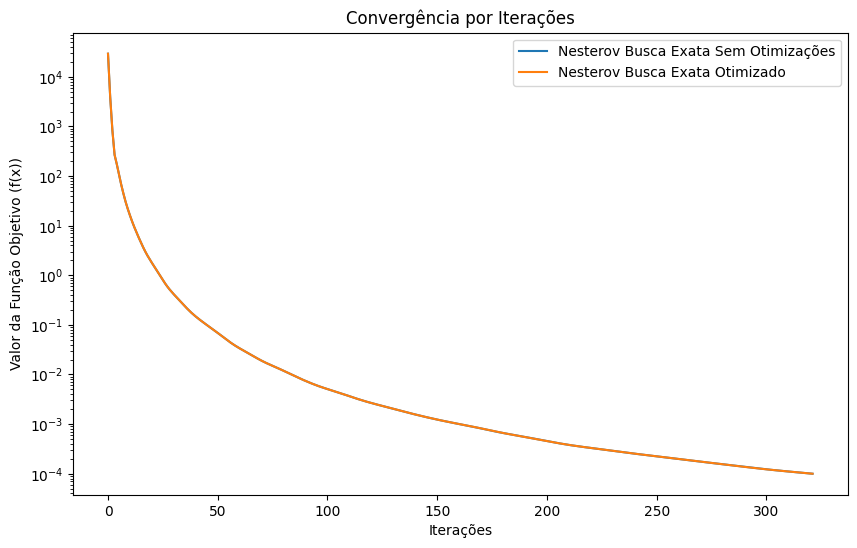

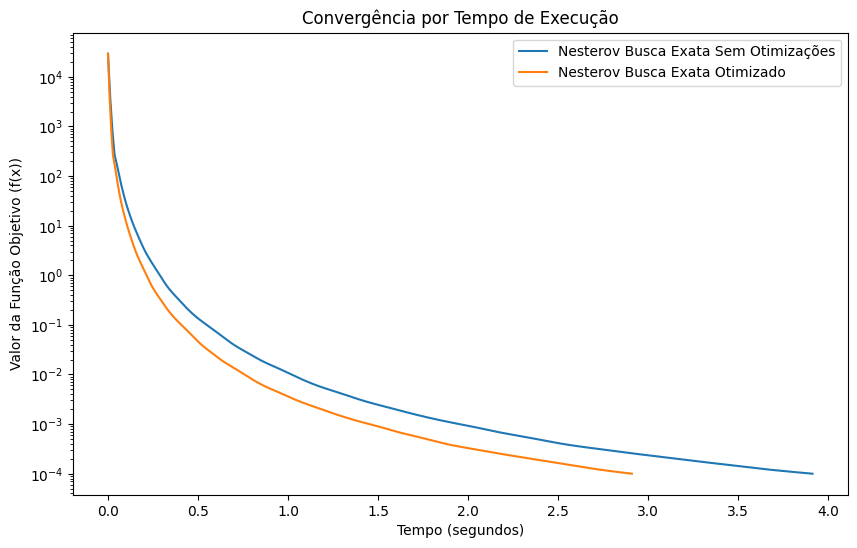

In [39]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "avg_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


In [40]:
x0 = torch.zeros_like( img )
tol = 1e-5
max_iter = 1000

In [41]:
methods = {
    "Nesterov Busca Exata Sem Otimizações" : lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato( f, grad_f, Q = Q, x = x0, tol = tol, max_iter = max_iter),
    "Nesterov Busca Exata Otimizado": lambda f, grad_f, x0, tol, max_iter: Algorithms.nesterov_exato_otimizado( f, grad_f, x = x0, A = radon, AT = radon_transpose, tol = tol, max_iter = max_iter )
}

results = compare_methods( methods, f, grad_f, x0, tol = tol, max_iter = max_iter )


Testando Nesterov Busca Exata Sem Otimizações (5 execuções)
Nesterov Busca Exata Sem Otimizações: 8.8132s ± 0.1111s ( 787 iterações )
Testando Nesterov Busca Exata Otimizado (5 execuções)
Nesterov Busca Exata Otimizado: 6.5647s ± 0.0421s ( 787 iterações )


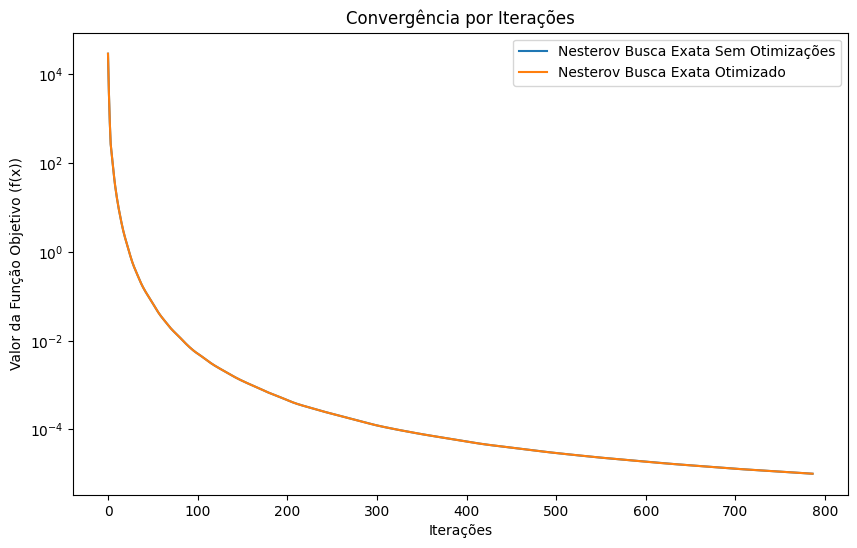

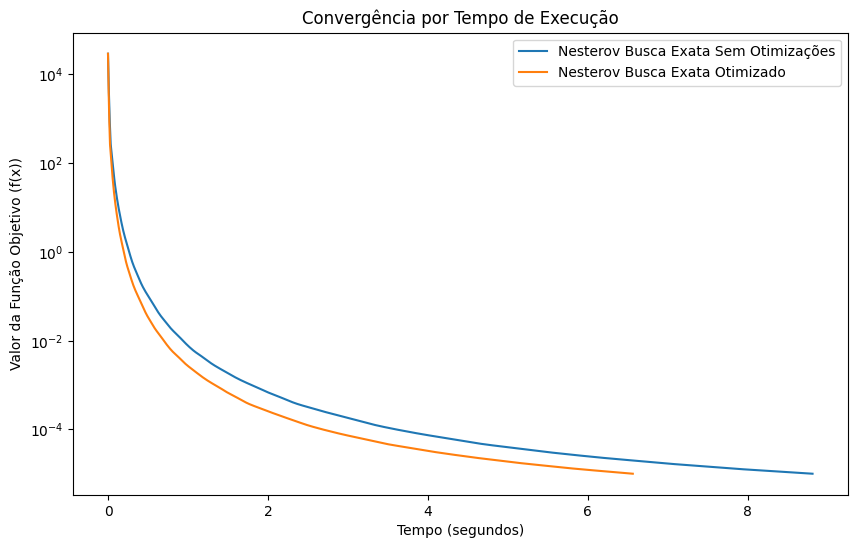

In [42]:
plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    plt.plot( res[ "function_values" ], label = name )
plt.xlabel( "Iterações" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Iterações" )
plt.show()

plt.figure( figsize = ( 10, 6 ) )
for name, res in results.items():
    times = torch.linspace( 0, res[ "avg_time" ], len( res[ "function_values" ] ) )
    plt.plot( times, res[ "function_values" ], label = name )
plt.xlabel( "Tempo (segundos)" )
plt.ylabel( "Valor da Função Objetivo (f(x))" )
plt.yscale( "log" )
plt.legend()
plt.title( "Convergência por Tempo de Execução" )
plt.show()


parece ser de 30-36% mais rápido 
